### This is a draft for python code my full analysis done using Excel & PowerBI and my work exist on Readme file in this Repo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('..\Data\Dataset.xlsx', sheet_name='fact')
df.head(1)

,Order ID,Order Date,Unit Cost,Price,Order Qty,Channel_ID,Promotion_ID,Product_ID,Manufacturer_ID,Product Sub Category_ID,Product Category_ID,Region_ID,City_ID,Country_ID,Order Date (Year),Order Date (Quarter),Order Date (Month Index),Order Date (Month),Price After Discount
0,252,2016-10-23,10,39.99,10,1,5,76,1,16,6,2,94,2,2016,Qtr4,10,Oct,1.9995


In [3]:
temp = pd.ExcelFile('..\Data\Dataset.xlsx')
temp.sheet_names

['dim region',
 'city',
 'dim channel',
 'dim category',
 'dim category sup',
 'dim product',
 'dim promotion',
 'fact',
 'Dim Country']

In [4]:
df = pd.merge(df, (pd.read_excel('..\Data\Dataset.xlsx', sheet_name='Dim Country')), on='Country_ID', how='left')
df.drop('Country_ID', axis=1, inplace=True)

df = pd.merge(df, (pd.read_excel('..\Data\Dataset.xlsx', sheet_name='dim promotion')), on='Promotion_ID', how='left')
df.drop('Promotion_ID', axis=1, inplace=True)

df = pd.merge(df, (pd.read_excel('..\Data\Dataset.xlsx', sheet_name='dim product')), on='Product_ID', how='left')
df.drop('Product_ID', axis=1, inplace=True)

df = pd.merge(df, (pd.read_excel('..\Data\Dataset.xlsx', sheet_name='dim category sup')), on='Product Sub Category_ID', how='left')
df.drop('Product Sub Category_ID', axis=1, inplace=True)

df = pd.merge(df, (pd.read_excel('..\Data\Dataset.xlsx', sheet_name='dim category')), on='Product Category_ID', how='left')
df.drop('Product Category_ID', axis=1, inplace=True)

df = pd.merge(df, (pd.read_excel('..\Data\Dataset.xlsx', sheet_name='dim channel')), on='Channel_ID', how='left')
df.drop('Channel_ID', axis=1, inplace=True)

df = pd.merge(df, (pd.read_excel('..\Data\Dataset.xlsx', sheet_name='dim region')), on='Region_ID', how='left')
df.drop('Region_ID', axis=1, inplace=True)

df = pd.merge(df, (pd.read_excel('..\Data\Dataset.xlsx', sheet_name='city')), on='City_ID', how='left')
df.drop('City_ID', axis=1, inplace=True)

df.drop('Manufacturer_ID', axis=1, inplace=True)
df.head(1)

,Order ID,Order Date,Unit Cost,Price,Order Qty,Order Date (Year),Order Date (Quarter),Order Date (Month Index),Order Date (Month),Price After Discount,Country,Promotion Name,Product Name,Product Sub Category,Product Category,Channel,Region,City
0,252,2016-10-23,10,39.99,10,2016,Qtr4,10,Oct,1.9995,United States,No Discount,Contoso Electronic Private Automatic Branch Ex...,Home & Office Phones,Cell phones,Store,North America,Bayonne


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15008 entries, 0 to 15007
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order ID                  15008 non-null  int64         
 1   Order Date                15008 non-null  datetime64[ns]
 2   Unit Cost                 15008 non-null  int64         
 3   Price                     15008 non-null  float64       
 4   Order Qty                 15008 non-null  int64         
 5   Order Date (Year)         15008 non-null  int64         
 6   Order Date (Quarter)      15008 non-null  object        
 7   Order Date (Month Index)  15008 non-null  int64         
 8   Order Date (Month)        15008 non-null  object        
 9   Price After Discount      15008 non-null  float64       
 10  Country                   15008 non-null  object        
 11  Promotion Name            15008 non-null  object        
 12  Product Name      

#### no null values

In [6]:
df.describe()

,Order ID,Order Date,Unit Cost,Price,Order Qty,Order Date (Year),Order Date (Month Index),Price After Discount
count,15008.000000,15008,15008.000000,15008.000000,15008.000000,15008.000000,15008.000000,15008.000000
mean,11211.093017,2017-09-29 02:13:16.375266560,124.880064,296.384554,16.738206,2017.236940,6.611207,176.877959
min,1.000000,2016-06-02 00:00:00,1.000000,0.950000,4.000000,2016.000000,1.000000,0.147000
25%,5631.750000,2016-12-24 00:00:00,17.000000,59.000000,9.000000,2016.000000,4.000000,14.990000
50%,11244.500000,2017-08-17 00:00:00,70.000000,205.000000,10.000000,2017.000000,7.000000,48.930000
75%,16788.250000,2018-06-18 00:00:00,165.000000,366.000000,13.000000,2018.000000,10.000000,259.990000
max,22353.000000,2019-06-02 00:00:00,1897.000000,2899.990000,1560.000000,2019.000000,12.000000,2899.990000
std,6450.682888,NaN,163.549698,345.947268,43.478761,0.955442,3.434994,280.002629


In [7]:
# df[df.duplicated()]
df.drop_duplicates(inplace=True)

In [8]:
df['Revenue'] = df['Order Qty'] * df['Price']
df[['Revenue']].head(1)

,Revenue
0,399.9


In [9]:
df['Profit'] = df['Revenue'] - df['Order Qty'] * df['Unit Cost']
df[['Profit']].head(1)

,Profit
0,299.9


In [10]:
df['Profit Margin'] = df['Profit'] / df['Revenue'] * 100
df[['Profit Margin']].head(1)

,Profit Margin
0,74.993748


In [11]:
df[['Revenue', 'Profit', 'Profit Margin']].head(1)

,Revenue,Profit,Profit Margin
0,399.9,299.9,74.993748


In [12]:
df.groupby('Product Category')[['Revenue','Profit']].sum().sort_values(ascending=False, by='Revenue').style.format({'Revenue': '${:,.1f}', 'Profit': '${:,.1f}'})

,Revenue,Profit
Product Category,,
Computers,"$21,629,439.0","$12,449,640.0"
Cameras and camcorders,"$17,336,727.9","$10,364,341.9"
TV and Video,"$9,257,732.6","$4,961,857.5"
Cell phones,"$5,918,974.3","$3,312,262.3"
"Music, Movies and Audio Books","$1,072,826.4","$645,700.4"
Audio,"$1,044,205.4","$587,503.4"


In [13]:
# df.groupby('Order Date (Year)')[['Revenue','Profit']].sum().sort_values(ascending=False, by='Revenue').style.format({'Revenue': '${:,.1f}', 'Profit': '${:,.1f}'})
years = df['Order Date'].dt.year
df.groupby(years)[['Revenue','Profit']].sum().sort_values(ascending=False, by='Revenue').style.format({'Revenue': '${:,.1f}', 'Profit': '${:,.1f}'})

,Revenue,Profit
Order Date,,
2017,"$19,339,771.8","$11,144,165.8"
2018,"$17,513,457.4","$10,136,412.4"
2016,"$11,974,641.1","$6,816,494.0"
2019,"$7,432,035.3","$4,224,233.3"


In [14]:
losses = df[df['Profit'] < 0]

#### I just do simple analysis on losses -> the goal is my python skill not analysis skills

In [15]:
losses.groupby('Product Category')[['Revenue','Profit']].sum().sort_values(ascending=False, by='Revenue').style.format({'Revenue': '${:,.1f}', 'Profit': '${:,.1f}'})

,Revenue,Profit
Product Category,,
Computers,"$142,885.0","$-1,775.1"
TV and Video,"$105,442.0","$-1,235.0"
Cell phones,"$70,275.0","$-3,446.0"
Cameras and camcorders,"$35,267.9",$-299.1
Audio,"$7,891.1",$-94.9
"Music, Movies and Audio Books","$6,292.9",$-115.1


In [16]:
# losses.groupby(['Product Sub Category', 'Order Date (Year)'])[['Revenue','Profit']].sum().sort_values(ascending=False, by='Revenue').style.format({'Revenue': '${:,.1f}', 'Profit': '${:,.1f}'})
losses.groupby(['Order Date (Year)'])[['Revenue','Profit']].sum().sort_values(ascending=False, by='Revenue').style.format({'Revenue': '${:,.1f}', 'Profit': '${:,.1f}'})

,Revenue,Profit
Order Date (Year),,
2018,"$147,876.3","$-2,728.7"
2017,"$86,711.3","$-1,473.7"
2019,"$76,799.1","$-1,905.9"
2016,"$56,667.0",$-857.0


In [17]:
losses.groupby(['Region'])[['Revenue','Profit']].sum().sort_values(ascending=False, by='Revenue').style.format({'Revenue': '${:,.1f}', 'Profit': '${:,.1f}'})

,Revenue,Profit
Region,,
North America,"$221,994.5","$-5,042.5"
Europe,"$74,846.3",$-967.7
Asia,"$71,213.0",$-955.0


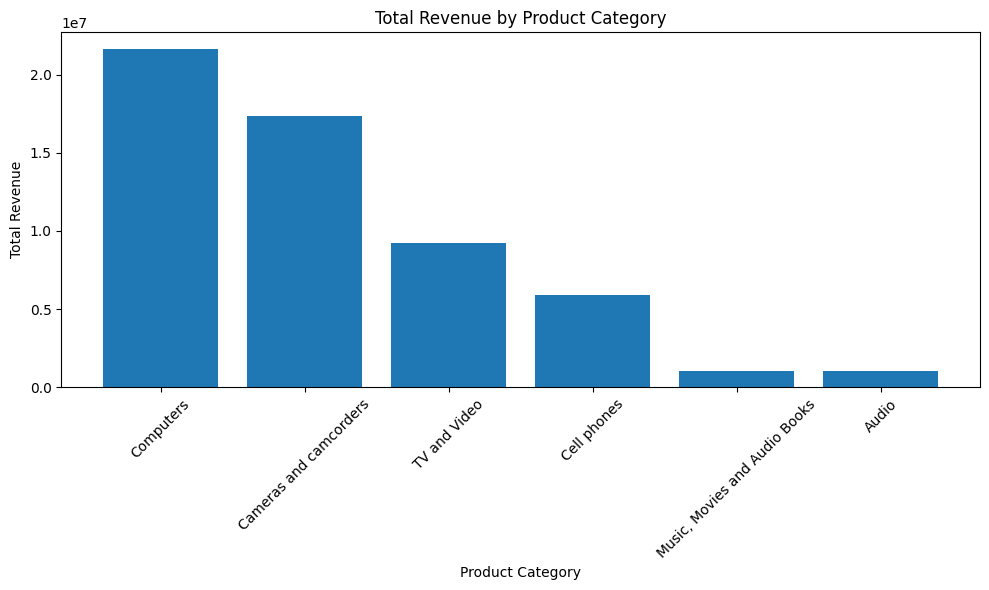

In [18]:
plt.figure(figsize=(10,6))
plt.bar(df.groupby('Product Category')['Revenue'].sum().sort_values(ascending=False).index, df.groupby('Product Category')['Revenue'].sum().sort_values(ascending=False).values)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\ahmed\AppData\Local\Temp\ipykernel_10336\2485860954.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Order Date (Year)', y='Revenue', estimator=sum, ci=None)


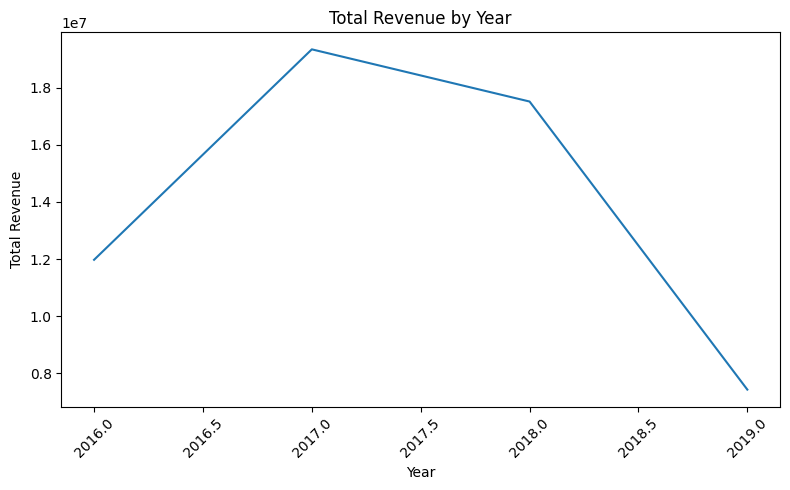

In [19]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='Order Date (Year)', y='Revenue', estimator=sum, ci=None)
plt.title('Total Revenue by Year')
plt.xlabel('Year')  
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
